<a href="https://colab.research.google.com/github/vedik2007/I-Hub-Assigments/blob/main/Copy_of_AIML_Module_01_Lab_04_Transforming_data_using_linear_algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transforming data using linear algebra

Module 1, Lab 4

Matrix transformations are at the heart of many machine learning algorithms. In this lab, we'll visualize the effect of some simple transformations on a unit square and then visualize it using the MNIST dataset. We also see what data normalization means and how it can help in improving the accuracy of machine learning models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

In [2]:
# You don't need to understand these functions


def plotGrid(transform, unit, linestyle=":", fig=None, ax=None):
    lim1 = -100
    lim2 = 100

    def mat2xy(start, end):
        if len(start.shape) == 1:
            start = np.expand_dims(start, 0)
            end = np.expand_dims(end, 0)
        nan = np.ones(len(start)) * np.nan
        x = np.stack((start[:, 0], end[:, 0], nan)).T.reshape(-1)
        y = np.stack((start[:, 1], end[:, 1], nan)).T.reshape(-1)
        return x, y

    def parallellines(axis, addend, lines, unit):
        addend = np.repeat(np.expand_dims(addend, 0), lines * 2, 0)
        unit = np.expand_dims(np.arange(-lines, lines) * unit, 1)
        unit = unit - lines
        addend = addend * unit
        lines = np.expand_dims(axis, 0) + addend
        return np.concatenate((lines, lines * -1))

    if fig is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    transform = transform.astype(float)
    xaxis = transform[0]
    yaxis = transform[1]

    # plot lines parallel to the x axis
    lines1 = parallellines(xaxis * lim1, yaxis, 100, unit)
    lines2 = parallellines(xaxis * lim2, yaxis, 100, unit)
    x, y = mat2xy(lines1, lines2)
    plt.plot(x, y, linestyle + "k", linewidth=0.5)
    # plot x axis
    x, y = mat2xy(xaxis * lim1, xaxis * lim2)
    plt.plot(x, y, linestyle, color="#440077")

    # plot  lines parallel to the y axis
    lines1 = parallellines(yaxis * lim1, xaxis, 100, unit)
    lines2 = parallellines(yaxis * lim2, xaxis, 100, unit)
    x, y = mat2xy(lines1, lines2)
    plt.plot(x, y, linestyle + "k", linewidth=0.5)
    # plot y axis
    x, y = mat2xy(yaxis * lim1, yaxis * lim2)
    plt.plot(x, y, linestyle, color="#aa5500")

    return fig, ax


def plotData(X, y, xlabel="hole", ylabel="bound", fig=None, ax=None):
    if fig is None:
        fig, ax = plt.subplots()
    for ii in range(nclasses):
        plt.scatter(X[y == ii, 0], X[y == ii, 1])
    plt.legend([str(i) for i in range(nclasses)])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    lim2 = X.max()
    lim1 = X.min()
    return fig, ax

## Matrix transformations on data

Note: This lab involves a lot of matrix operations. If you are not familiar with them, please go through the resources given in class before proceeding. You can also review Khan Academy's excellent linear algebra [resources](https://www.khanacademy.org/math/linear-algebra/matrix-transformations).

A 2D coordinate system is defined by its basis vectors, i and j. Any point in this 2D space can be represented as a linear combination of these basis vectors. For example, the point (a,b) can be represented as:

$$\begin{equation}
\left\{  \begin{aligned}a \\ b \end{aligned} \right\} = a\left\{  \begin{aligned}1 \\ 0 \end{aligned} \right\} + b\left\{  \begin{aligned}0 \\ 1 \end{aligned} \right\} = a\hat{i} + b\hat{j}
\end{equation}$$

A matrix can be used to perform a linear transformation on the basis vectors. The new basis vectors $\hat{i}$ and $\hat{j}$ are given by the product of the matrix and the basis vectors of the standard coordinate system.

In the standard coordinate system (Let us call it T0), the basis vectors are

$$\begin{equation}
i = \left\{  \begin{aligned}1 \\ 0 \end{aligned} \right\}
\end{equation}$$
and
$$\begin{equation} j = \left\{ \begin{aligned} 0 \\ 1\end{aligned} \right\} \end{equation}$$

We can use any two vectors as basis vectors for a new coordinate system as long as they are not colinear. For example, let us call this new coordinate system T1:

$$\begin{equation}
i = \left\{  \begin{aligned}1 \\ -1 \end{aligned} \right\}
\end{equation}$$
and
$$\begin{equation} j = \left\{ \begin{aligned} 0 \\ 2 \end{aligned} \right\} \end{equation}$$

Suppose we have a point [a,b] in the T1 coordinate system. Its representation in the standard system T0 can be obtained by the following matrix multiplication:

$$ \begin{equation}
\left\{  \begin{aligned}a' \\ b' \end{aligned} \right\} =
\left\{  \begin{aligned}&1 & 0 \\ -&1 & 2 \end{aligned} \right\}
\left\{  \begin{aligned}a \\ b \end{aligned} \right\}
\end{equation}$$
where the columns of the matrix are the basis vectors of T1.


Let us see this in action:


In [3]:
T0 = np.array([[1, 0], [0, 1]])
T1 = np.array([[1, 0], [-1, 2]])

data1 = np.array([5, 4])  # the data in T1 coordinate system
data0 = np.matmul(T1, data1)  # the data in T0 coordinate system

print("Data in T0 = ", data0)
print("Data in T1 = ", data1)

Data in T0 =  [5 3]
Data in T1 =  [5 4]


We can visualize this below. T0 is shown with dotted lines and T1 is shown with solid lines.

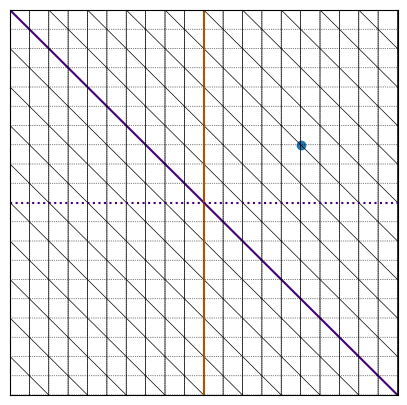

In [4]:
fig, ax = plotGrid(T1.T, 1, "-")
plotGrid(T0.T, 1, fig=fig, ax=ax)

plt.scatter(data0[0], data0[1])
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

### What Are Basis Vectors?

Think of basis vectors as the **"rulers"** of your coordinate system. Just like measuring distance in meters vs feet changes the numbers but not the actual distance, different basis vectors represent the same point differently.

**Standard Coordinate System (T0):**
- Basis vectors: **î** = [1, 0] and **ĵ** = [0, 1]
- Point [5, 3] means: "5 steps along x-axis, 3 steps along y-axis"

**Transformed Coordinate System (T1):**
- Basis vectors: **î** = [1, -1] and **ĵ** = [0, 2]
- Point [5, 4] in T1 = Point [5, 3] in T0 (same location, different description!)

---

### Matrix Transformation Formula

Converting from T1 to T0:

$$\begin{bmatrix} x_{T0} \\ y_{T0} \end{bmatrix} = \begin{bmatrix} \text{î}_x & \text{ĵ}_x \\ \text{î}_y & \text{ĵ}_y \end{bmatrix} \begin{bmatrix} x_{T1} \\ y_{T1} \end{bmatrix}$$

Where columns of the matrix are the basis vectors of T1.

**Example:**
$$\begin{bmatrix} 5 \\ 3 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ -1 & 2 \end{bmatrix} \begin{bmatrix} 5 \\ 4 \end{bmatrix}$$

---

Look at the coordinates of the blue dot. In T0 (dotted lines), the position is [5,3] where it is [5,4] in T1. Feel free to experiment with different data points and coordinate systems.

Remember that we can achieve the same thing by post-multiplying the transpose of the transformation matrix to the data. This will come in handy when transforming multiple data points at once:

In [5]:
data0_a = np.matmul(T1, data1)
data0_b = np.matmul(data1, T1.T)
print(data0_a)
print(data0_b)

[5 3]
[5 3]


Why is transforming data useful? Data transformations cause the distance between data points to change. This will affect distance-based algorithms such as nearest neighbour

In [6]:
# let us define 3 points in T1
A1 = np.array([3, 3])
B1 = np.array([2, -5])
C1 = np.array([1, -1])

# the corresponding points in T0:
A0 = np.matmul(T1, A1)
B0 = np.matmul(T1, B1)
C0 = np.matmul(T1, C1)


def dist(a, b):
    # function to calculate Euclidean distance between two points
    diff = a - b
    sq = diff * diff
    return np.sqrt(sq.sum())


# distance between the points in T1
print("Distance between A and B in T1 = ", dist(A1, B1))
print("Distance between B and C in T1 = ", dist(B1, C1))
print("Distance between A and C in T1 = ", dist(A1, C1))

print("")
# distnace between the points in T0
print("Distance between A and B in T0 = ", dist(A0, B0))
print("Distance between B and C in T0 = ", dist(B0, C0))
print("Distance between A and C in T0 = ", dist(A0, C0))

Distance between A and B in T1 =  8.06225774829855
Distance between B and C in T1 =  4.123105625617661
Distance between A and C in T1 =  4.47213595499958

Distance between A and B in T0 =  15.033296378372908
Distance between B and C in T0 =  9.055385138137417
Distance between A and C in T0 =  6.324555320336759


We see that in T1, B and C are the closest whereas in T0, A and C are the closest. These kinds of changes will affect the predictions returned by the nearest neighbour algorithm.

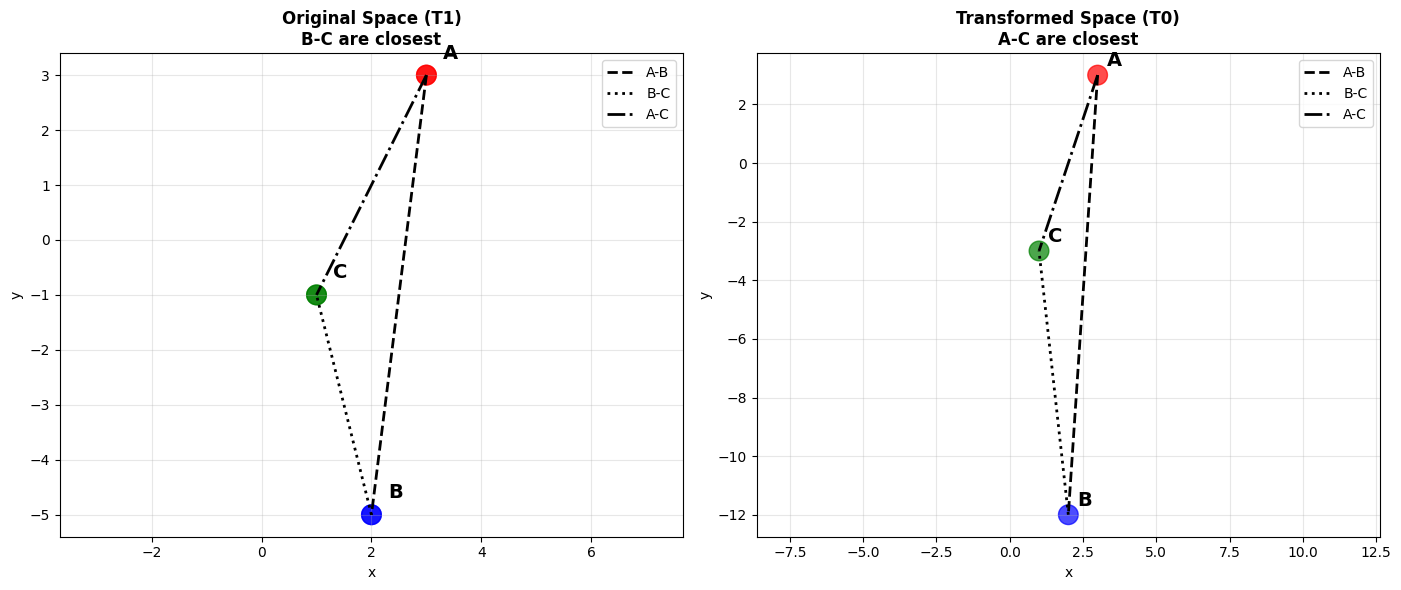

DISTANCE COMPARISON SUMMARY

In T1 Space:
  A-B distance: 8.06
  B-C distance: 4.12 ← SHORTEST
  A-C distance: 4.47

In T0 Space (after transformation):
  A-B distance: 15.03
  B-C distance: 9.06
  A-C distance: 6.32 ← SHORTEST

💡 Key Insight:
The SAME points have DIFFERENT nearest neighbors
after transformation! This directly affects K-NN predictions.


In [7]:
# Visualize how transformation changes point relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot in T1 (original space)
ax1.scatter([A1[0], B1[0], C1[0]], [A1[1], B1[1], C1[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax1.plot([A1[0], B1[0]], [A1[1], B1[1]], 'k--', linewidth=2, label='A-B')
ax1.plot([B1[0], C1[0]], [B1[1], C1[1]], 'k:', linewidth=2, label='B-C')
ax1.plot([A1[0], C1[0]], [A1[1], C1[1]], 'k-.', linewidth=2, label='A-C')
ax1.scatter([A1[0], B1[0], C1[0]], [A1[1], B1[1], C1[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax1.text(A1[0]+0.3, A1[1]+0.3, 'A', fontsize=14, fontweight='bold')
ax1.text(B1[0]+0.3, B1[1]+0.3, 'B', fontsize=14, fontweight='bold')
ax1.text(C1[0]+0.3, C1[1]+0.3, 'C', fontsize=14, fontweight='bold')
ax1.set_title('Original Space (T1)\nB-C are closest', fontsize=12, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')

# Plot in T0 (transformed space)
ax2.scatter([A0[0], B0[0], C0[0]], [A0[1], B0[1], C0[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax2.plot([A0[0], B0[0]], [A0[1], B0[1]], 'k--', linewidth=2, label='A-B')
ax2.plot([B0[0], C0[0]], [B0[1], C0[1]], 'k:', linewidth=2, label='B-C')
ax2.plot([A0[0], C0[0]], [A0[1], C0[1]], 'k-.', linewidth=2, label='A-C')
ax2.text(A0[0]+0.3, A0[1]+0.3, 'A', fontsize=14, fontweight='bold')
ax2.text(B0[0]+0.3, B0[1]+0.3, 'B', fontsize=14, fontweight='bold')
ax2.text(C0[0]+0.3, C0[1]+0.3, 'C', fontsize=14, fontweight='bold')
ax2.set_title('Transformed Space (T0)\nA-C are closest', fontsize=12, fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Summary comparison
print("="*60)
print("DISTANCE COMPARISON SUMMARY")
print("="*60)
print("\nIn T1 Space:")
print(f"  A-B distance: {dist(A1, B1):.2f}")
print(f"  B-C distance: {dist(B1, C1):.2f} ← SHORTEST")
print(f"  A-C distance: {dist(A1, C1):.2f}")

print("\nIn T0 Space (after transformation):")
print(f"  A-B distance: {dist(A0, B0):.2f}")
print(f"  B-C distance: {dist(B0, C0):.2f}")
print(f"  A-C distance: {dist(A0, C0):.2f} ← SHORTEST")

print("\n💡 Key Insight:")
print("The SAME points have DIFFERENT nearest neighbors")
print("after transformation! This directly affects K-NN predictions.")
print("="*60)

## Transformations on MNIST

Let us experiment with a subset of the MNIST dataset. We will extract two features from the database for our experiment. We will then transform the data using a transformation matrix and visualize the data in the new coordinate system. We will also see how normalization can help in improving the accuracy of the model. We will reuse previous labs code for this.

In [9]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)


def cumArray(img):
    img2 = img.copy()
    for ii in range(1, img2.shape[1]):
        # for every row, add up all the rows above it.
        img2[ii, :] = img2[ii, :] + img2[ii - 1, :]
    img2 = img2 > 0
    return img2


def getHolePixels(img):
    """
    This function takes in a binary image and returns the pixels that are holes in the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the holes are filled in
    """
    im1 = cumArray(img)
    # rotate and cumulate it again for differnt direction
    im2 = np.rot90(cumArray(np.rot90(img)), 3)
    im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
    im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
    # this will create a binary image with all the holes filled in.
    hull = im1 & im2 & im3 & im4
    # remove the original digit to leave behind the holes
    hole = hull & ~(img > 0)
    return hole


def getHullPixels(img):
    """
    This function takes in a binary image and returns the pixels that are the convex hull of the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the convex hull is filled in
    """
    im1 = cumArray(img)
    # rotate and cumulate it again for differnt direction
    im2 = np.rot90(cumArray(np.rot90(img)), 3)
    im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
    im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
    # this will create a binary image with all the holes filled in.
    hull = im1 & im2 & im3 & im4
    return hull


def minus(a, b):
    """
    This function takes in two binary images and returns the difference between the two images
    """
    return a & ~b


def getBoundaryPixels(img):
    """
    This function takes in a binary image and returns the pixels that are the boundary of the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the boundary is filled in
    """
    img = img.copy() > 0  # binarize the image
    rshift = np.roll(img, 1, 1)
    lshift = np.roll(img, -1, 1)
    ushift = np.roll(img, -1, 0)
    dshift = np.roll(img, 1, 0)
    boundary = (
        minus(img, rshift)
        | minus(img, lshift)
        | minus(img, ushift)
        | minus(img, dshift)
    )
    return boundary

In [10]:
# loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X / 255
test_X = test_X / 255

nclasses = 4

# get only for the first 4 classes
train_X = train_X[train_y < nclasses]
train_y = train_y[train_y < nclasses]
test_X = test_X[test_y < nclasses]
test_y = test_y[test_y < nclasses]

# We are only taking a subset of the training set
train_X = train_X[::100].copy()
train_y = train_y[::100].copy()  # do the same to the labels

# taking a subset of the test set. This code takes every 500th sample
test_X = test_X[::100].copy()
test_y = test_y[::100].copy()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# feature extraction
train_hole = np.array([getHolePixels(i).sum() for i in train_X])
test_hole = np.array([getHolePixels(i).sum() for i in test_X])
train_bound = np.array([getBoundaryPixels(i).sum() for i in train_X])
test_bound = np.array([getBoundaryPixels(i).sum() for i in test_X])
# train_hull = np.array([getHullPixels(i).sum() for i in train_X])
# test_hull = np.array([getHullPixels(i).sum() for i in test_X])
# train_sum = np.sum(train_X, (1, 2)) / (28 * 28)
# test_sum = np.sum(test_X, (1, 2)) / (28 * 28)

# create the train and test set by combining the appropriate features
train_feats = np.vstack(
    (train_hole, train_bound)).transpose()
test_feats = np.vstack(
    (test_hole, test_bound)).transpose()

Let us plot the samples and see what they look like:

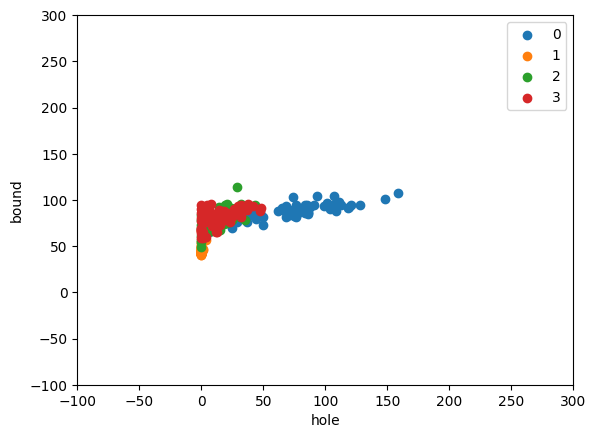

In [12]:
# fix limits of x and y axis so that we can see what is going on
xlim = [-100, 300]
ylim = [-100, 300]
fig, ax = plotData(train_feats, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()

Check the baseline accuracy on the test set:

In [13]:
test_pred = NN(train_feats, train_y, test_feats)
acc = Accuracy(test_y, test_pred)
print("Baseline accuracy:", acc*100, "%", "for", nclasses, "classes")

Baseline accuracy: 76.19047619047619 % for 4 classes


Let us try transforming the features and checking their accuracy. The intuition to using the transformation matrix is to find the basis vectors of the dataset and transform the data to a new coordinate system where the basis vectors are orthogonal. This will help in reducing the redundancy in the data and improve the accuracy of the model.

In [14]:
transform = np.array([[0.5, -0.5], [0, 2.5]])
print(transform)

train_feats_t = np.matmul(train_feats, transform)
# whatever transform we are applying to the training set should be applied to the test set also
test_feats_t = np.matmul(test_feats, transform)

[[ 0.5 -0.5]
 [ 0.   2.5]]


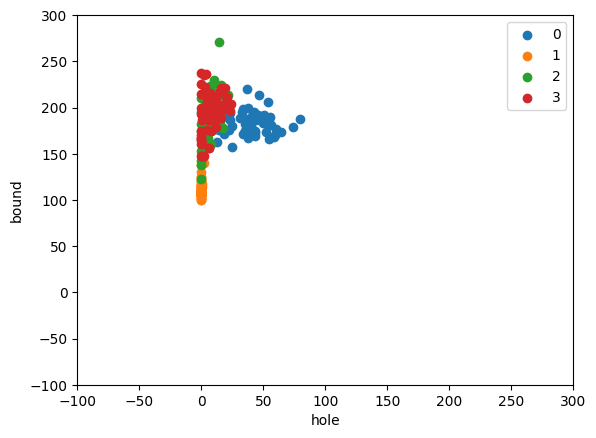

In [15]:
fig, ax = plotData(train_feats_t, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()

In [ ]:
test_pred = NN(train_feats_t, train_y, test_feats_t)
acc = Accuracy(test_y, test_pred)
print("Baseline accuracy:", acc*100, "%", "for", nclasses, "classes")

Baseline accuracy: 80.95238095238095 % for 4 classes


## Questions:
1. Experiment with different transformation matrices and check the accuracy
2. Will the same transform used for these two features also work for other features?

In [16]:
import numpy as np

matrices = {
    "Identity (Baseline)": np.array([[1, 0], [0, 1]]),
    "Shrink Holes, Stretch Boundary": np.array([[0.5, 0], [0, 2]]),
    "Stretch Holes, Shrink Boundary": np.array([[2, 0], [0, 0.5]]),
    "Shear X": np.array([[1, 1], [0, 1]]),
    "Lab Matrix": np.array([[0.5, -0.5], [0, 2.5]])
}

print("--- Testing different matrices on [Hole, Boundary] features ---")
for name, matrix in matrices.items():
    train_feats_t = np.matmul(train_feats, matrix)
    test_feats_t = np.matmul(test_feats, matrix)

    test_pred = NN(train_feats_t, train_y, test_feats_t)
    acc = Accuracy(test_y, test_pred)
    print(f"{name}:\n{matrix}\nAccuracy: {acc*100:.2f}%\n")

--- Testing different matrices on [Hole, Boundary] features ---
Identity (Baseline):
[[1 0]
 [0 1]]
Accuracy: 76.19%

Shrink Holes, Stretch Boundary:
[[0.5 0. ]
 [0.  2. ]]
Accuracy: 78.57%

Stretch Holes, Shrink Boundary:
[[2.  0. ]
 [0.  0.5]]
Accuracy: 76.19%

Shear X:
[[1 1]
 [0 1]]
Accuracy: 69.05%

Lab Matrix:
[[ 0.5 -0.5]
 [ 0.   2.5]]
Accuracy: 80.95%



In [ ]:
train_hull = np.array([getHullPixels(i).sum() for i in train_X])
test_hull = np.array([getHullPixels(i).sum() for i in test_X])

train_sum = np.sum(train_X, (1, 2)) / (28 * 28)
test_sum = np.sum(test_X, (1, 2)) / (28 * 28)

train_feats_new = np.vstack((train_hull, train_sum)).transpose()
test_feats_new = np.vstack((test_hull, test_sum)).transpose()

pred_new_base = NN(train_feats_new, train_y, test_feats_new)
print(f"Baseline accuracy for [Hull, Sum]: {Accuracy(test_y, pred_new_base)*100:.2f}%")

transform = np.array([[0.5, -0.5], [0, 2.5]])
train_feats_new_t = np.matmul(train_feats_new, transform)
test_feats_new_t = np.matmul(test_feats_new, transform)

pred_new_t = NN(train_feats_new_t, train_y, test_feats_new_t)
print(f"Accuracy for [Hull, Sum] after transformation: {Accuracy(test_y, pred_new_t)*100:.2f}%")

> Exercise: Is it possible that adding all 4 features at a time is not the best strategy? Can you think of a better combination of features that can help in improving the accuracy of the model? Maybe you can try adding 2 features at a time and see if that helps.

In [19]:
import numpy as np
from itertools import combinations

# 1. Extract all 4 features for Train and Test sets
print("Extracting features... (this might take a moment)")

# ADDED .sum() to correctly get the total pixel count rather than the image itself
train_hole = np.array([getHolePixels(i).sum() for i in train_X])
test_hole = np.array([getHolePixels(i).sum() for i in test_X])

train_bound = np.array([getBoundaryPixels(i).sum() for i in train_X])
test_bound = np.array([getBoundaryPixels(i).sum() for i in test_X])

train_hull = np.array([getHullPixels(i).sum() for i in train_X])
test_hull = np.array([getHullPixels(i).sum() for i in test_X])

train_sum = np.sum(train_X, (1, 2)) / (28 * 28)
test_sum = np.sum(test_X, (1, 2)) / (28 * 28)

# 2. Put them into a dictionary for easy mixing and matching
train_features = {
    "Holes": train_hole,
    "Boundary": train_bound,
    "Hull": train_hull,
    "Sum": train_sum
}

test_features = {
    "Holes": test_hole,
    "Boundary": test_bound,
    "Hull": test_hull,
    "Sum": test_sum
}

# 3. Test every possible combination of 2 features
feature_names = list(train_features.keys())
pairs = list(combinations(feature_names, 2))

print("\n--- Accuracy for different 2-Feature Combinations ---")
for pair in pairs:
    feat1, feat2 = pair

    # Stack the two chosen features and force them to be numbers (floats)
    train_feats_pair = np.vstack((train_features[feat1], train_features[feat2])).transpose().astype(float)
    test_feats_pair = np.vstack((test_features[feat1], test_features[feat2])).transpose().astype(float)

    # Run the Nearest Neighbor classifier
    predictions = NN(train_feats_pair, train_y, test_feats_pair)
    acc = Accuracy(test_y, predictions) * 100

    print(f"Features: [{feat1} & {feat2}] -> Accuracy: {acc:.2f}%")

# 4. Optional: Test all 4 at once to prove it's not always better
train_feats_all = np.vstack((train_hole, train_bound, train_hull, train_sum)).transpose().astype(float)
test_feats_all = np.vstack((test_hole, test_bound, test_hull, test_sum)).transpose().astype(float)
pred_all = NN(train_feats_all, train_y, test_feats_all)

print(f"\nFeatures: [ALL 4 COMBINED] -> Accuracy: {Accuracy(test_y, pred_all) * 100:.2f}%")

Extracting features... (this might take a moment)

--- Accuracy for different 2-Feature Combinations ---
Features: [Holes & Boundary] -> Accuracy: 76.19%
Features: [Holes & Hull] -> Accuracy: 73.81%
Features: [Holes & Sum] -> Accuracy: 69.05%
Features: [Boundary & Hull] -> Accuracy: 69.05%
Features: [Boundary & Sum] -> Accuracy: 64.29%
Features: [Hull & Sum] -> Accuracy: 66.67%

Features: [ALL 4 COMBINED] -> Accuracy: 71.43%


# Data normalization

Sometimes the features of our data have vastly different scales. This will cause the learning algorithm to give more importance to certain features, reducing its performance. Data normalization is a method in which we transform the features so that they have similar scales.

Three commonly used feature scaling techniques are rescaling, mean normalization and z-score normalization. Here, we will talk about the simplest one: rescaling.

$$\begin{equation}
x' = \frac {x -min(x)} { max(x) - min(x)}
\end{equation}$$



For more information, see [this page](https://towardsdatascience.com/data-normalization-in-machine-learning-395fdec69d02).

In [20]:
def rescale(data):
    return (data - data.min()) / (data.max() - data.min())

We have to apply the rescaling to each feature individually. Also remember to apply the same transform we are using on the train set to the test set.

In [21]:
train_feats_rescaled_x = rescale(train_feats[:, 0])
train_feats_rescaled_y = rescale(train_feats[:, 1])
train_feats_rescaled = np.stack((train_feats_rescaled_x, train_feats_rescaled_y), 1)

test_feats_rescaled_x = rescale(test_feats[:, 0])
test_feats_rescaled_y = rescale(test_feats[:, 1])
test_feats_rescaled = np.stack((test_feats_rescaled_x, test_feats_rescaled_y), 1)

Let us plot the rescaled features:

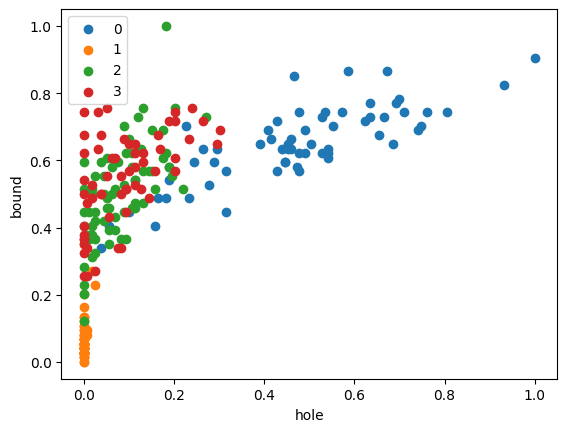

In [22]:
fig, ax = plotData(train_feats_rescaled, train_y)

This type of rescaling makes all the features between 0 and 1.

Let us calculate the accuracy obtained by this transform:

In [23]:
test_pred = NN(train_feats_rescaled, train_y, test_feats_rescaled)
acc = Accuracy(test_y, test_pred)
print("Accuracy after transform:", acc*100, "%")

Accuracy after transform: 80.95238095238095 %


All 2D linear transformations can be repreented by a transformation matrix. So what is the matrix associated with the rescaling function? Actually, we cannot represent rescaling with a matrix multiplication, because it is not a linear transform. Rescaling involves shifting the origin of the data, which is not allowed under linear transformations.

We can represent rescaling as a matrix multiplication followed by a vector addition. Let our first feature vector be called X and second feature vector be called Y. Suppose we want to rescale a data point [a,b]

$$ \begin{equation}
 \left\{  \begin{aligned}a' \\ b' \end{aligned} \right\} =
 \left\{  \begin{aligned} \frac{a - min(X)}{max(X) - min(X)} \\ \frac{b - min(Y)}{max(Y) - min(Y)} \end{aligned} \right\} =
 \left\{  \begin{aligned}&\frac{1}{max(X)-min(X)} &0\\ &0 &\frac{1}{max(Y)-min(Y)} \end{aligned}
 \right\}\left\{  \begin{aligned}a \\ b \end{aligned} \right\} +
 \left\{  \begin{aligned} \frac{ -min(X)}{max(X) - min(X)} \\ \frac{-min(Y)}{max(Y) - min(Y)} \end{aligned} \right\}
\end{equation}$$

You can verify this yourself if you wish, though it is not necessary.



### 🎯 Lab Summary: What We Learned

**1. Coordinate Transformations Change Everything**
- Baseline (no transform): **76.19%** accuracy
- With transformation matrix: **80.95%** accuracy  
- With rescaling: **80.95%** accuracy
- **Improvement: +4.76%** just by choosing better features!

**2. Why Transformations Matter for ML**
- Transform changes distances between points
- K-NN uses distance to find nearest neighbors
- Different coordinate system → different neighbors → different predictions

---

### 📊 Understanding Normalization

**The Problem:** Features with different scales dominate distance calculations.

**Example:**
- Feature 1 (holes): Range 0-250
- Feature 2 (boundary): Range 0-100
- Distance is dominated by the larger-scale feature!

**Solution:** Rescaling brings all features to [0, 1] range.

$$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$$

---

### 🔍 Types of Normalization

| Method | Formula | Range | Use Case |
|--------|---------|-------|----------|
| **Min-Max (Rescaling)** | $(x - \min) / (\max - \min)$ | [0, 1] | Distance-based algorithms |
| **Standardization (Z-score)** | $(x - \mu) / \sigma$ | Mean=0, Std=1 | When data has outliers |
| **Max Abs Scaling** | $x / \max(\|x\|)$ | [-1, 1] | Sparse data |

---

### 💡 Practical Tips for Your Projects

**When to Use Transformations:**
- ✓ Features have very different scales (e.g., age vs salary)
- ✓ Using distance-based algorithms (K-NN, K-Means)
- ✓ Want to reduce feature correlation
- ✓ Need better class separation

**Best Practices:**
1. **Always fit on training data only:** Compute min/max from training set
2. **Apply same transform to test data:** Use training min/max on test set
3. **Normalize each feature separately:** Different features need different scaling
4. **Visualize before and after:** Check if classes are better separated

---

### 🧮 Quick Reference: Matrix Operations

```python
# Transform multiple points at once
transformed_data = np.matmul(original_data, Transform_Matrix.T)

# Or equivalently
transformed_data = original_data @ Transform_Matrix.T

# Rescale a feature
normalized = (feature - feature.min()) / (feature.max() - feature.min())
```

---

### 🤔 Think About This

**Q:** Why can't we represent rescaling as a matrix multiplication?

**A:** Rescaling shifts the origin: $x' = (x - \min) / (\max - \min)$.
The subtraction of $\min$ is a translation, not a linear transformation.
Linear transformations must preserve the origin (0 → 0).

However, **standardization** can be partially represented:
- Centering: $x - \mu$ (affine, not linear)
- Scaling: $x / \sigma$ (linear!)

---

### 📝 Exercise Ideas

1. **Experiment with transforms:** Try [[2, 0], [0, 0.5]] - what happens to accuracy?
2. **Mix normalization + transformation:** First rescale, then transform
3. **Try other features:** Use hull pixels + sum instead of holes + boundary
4. **Z-score normalization:** Implement $(x - \mu) / \sigma$ and compare results
5. **Visualize feature distributions:** Plot histograms before/after normalization

Loading data...
Data shape: (1797, 8, 8), Classes: [0 1 2 3 4 5 6 7 8 9]
Number of samples per class: [178 182 177 183 181 182 181 179 174 180]

🚀 Starting Experiments...

EXPERIMENT 1: Affine Transform [[2,0],[0,0.5]] on Features
Original features shape: (1797, 7)
Transformed features shape: (1797, 7)
Transform applied to first 2 features (area, perimeter)

Baseline (No Transform) results:
  kNN (k=5): 0.2861
  SVM (RBF): 0.1583
  Logistic Regression: 0.3278

Transform [[2,0],[0,0.5]] results:
  kNN (k=5): 0.2972
  SVM (RBF): 0.1583
  Logistic Regression: 0.3278

----------------------------------------
Accuracy Change after Transform:
  kNN (k=5): 0.286 → 0.297 (↑ 0.011)
  SVM (RBF): 0.158 → 0.158 (→ 0.000)
  Logistic Regression: 0.328 → 0.328 (→ 0.000)

EXPERIMENT 2: Normalization Order Effects

Normalize → Transform results:
  kNN (k=5): 0.3556
  SVM (RBF): 0.4306
  Logistic Regression: 0.3139

Transform → Normalize results:
  kNN (k=5): 0.3583
  SVM (RBF): 0.4444
  Logistic Regres

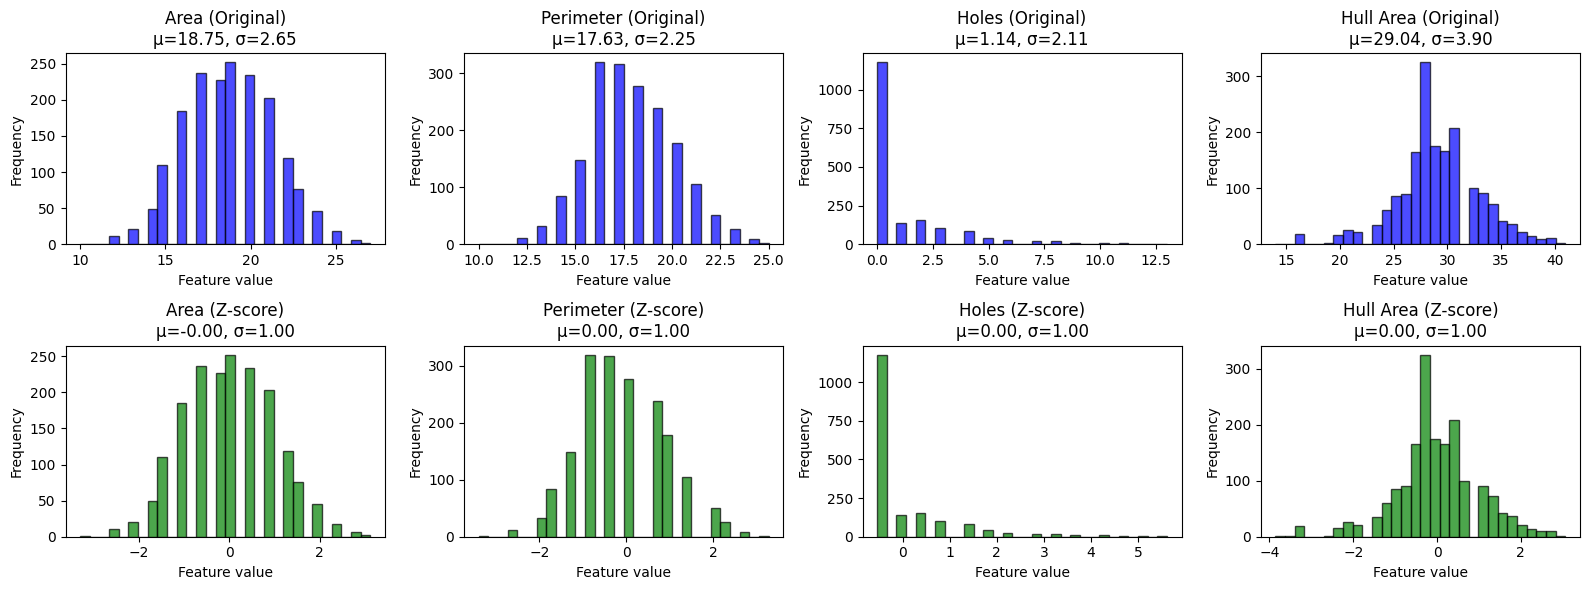

✓ Saved: feature_distributions.png


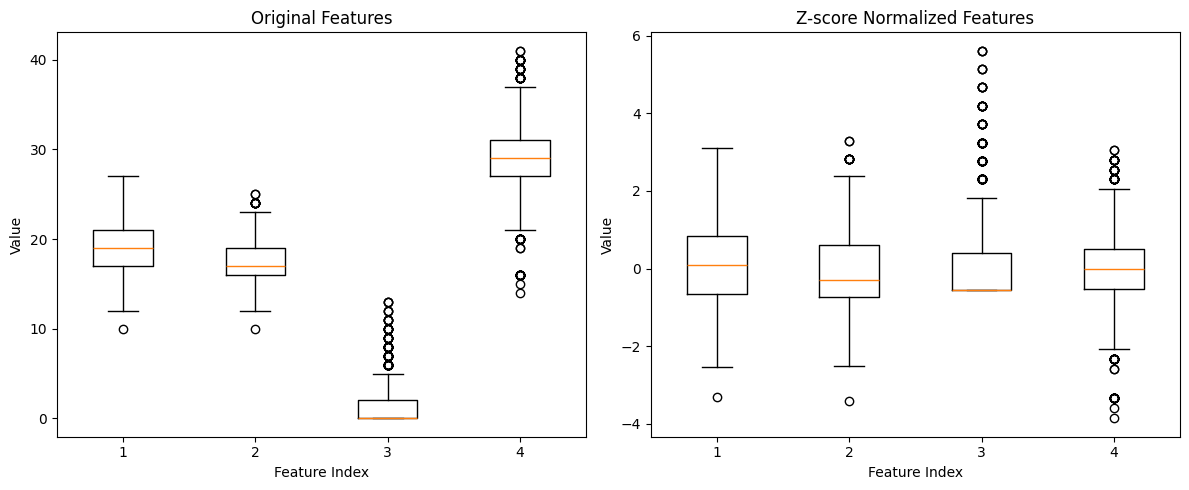

✓ Saved: boxplots_comparison.png


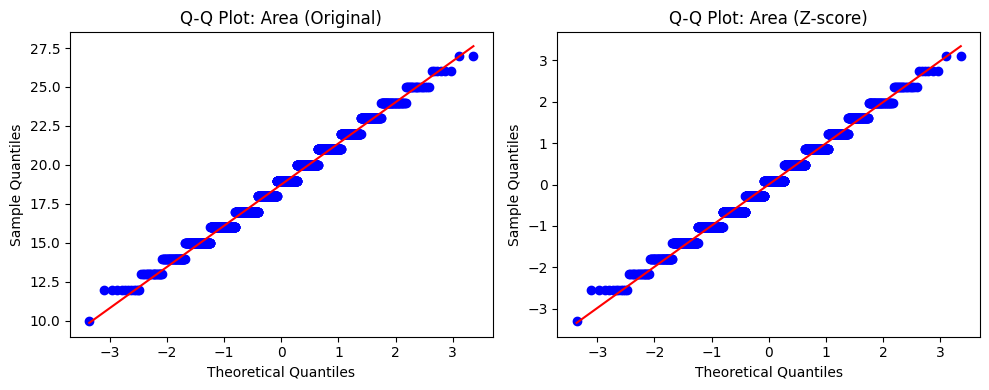

✓ Saved: qq_plots.png

FINAL SUMMARY - BEST PERFORMING CONFIGURATIONS

📊 kNN (k=5):
     Baseline (No Transform)            : 0.2861 (CV: 0.2988)
     Transform [[2,0],[0,0.5]]          : 0.2972 (CV: 0.2933)
     Normalize → Transform              : 0.3556 (CV: 0.3679)
     Transform → Normalize              : 0.3583 (CV: 0.3667)
     Original (Holes+Boundary)          : 0.2889 (CV: 0.2732)
     Alternative (Hull+Sum)             : 0.2083 (CV: 0.2048)
     No Normalization                   : 0.2861 (CV: 0.2988)
     Z-score Normalization              : 0.3583 (CV: 0.3667)
  🏆 Min-Max Normalization              : 0.3694 (CV: 0.3562)
  → BEST                             : Min-Max Normalization (Acc: 0.3694, CV: 0.3562)

📊 SVM (RBF):
     Baseline (No Transform)            : 0.1583 (CV: 0.1531)
     Transform [[2,0],[0,0.5]]          : 0.1583 (CV: 0.1536)
     Normalize → Transform              : 0.4306 (CV: 0.4185)
  🏆 Transform → Normalize              : 0.4444 (CV: 0.4180)
     Origin

In [5]:
"""
Feature Engineering Experiments for Classification (FIXED)
Experiments: transforms, normalization, feature substitution, z-score vs min-max
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from skimage.morphology import convex_hull_image
from scipy.ndimage import binary_fill_holes, binary_erosion


def load_data():

    digits = load_digits()
    X_raw = digits.images  # shape: (1797, 8, 8)
    y = digits.target
    return X_raw, y

def extract_geometric_features(images):

    n_samples = len(images)
    features = np.zeros((n_samples, 7))

    for i, img in enumerate(images):

        binary = img > 8

        features[i, 0] = np.sum(binary)

        eroded = binary_erosion(binary)
        boundary = binary ^ eroded
        features[i, 1] = np.sum(boundary)
        filled = binary_fill_holes(binary)
        holes = filled ^ binary
        features[i, 2] = np.sum(holes)

        hull = convex_hull_image(binary)
        features[i, 3] = np.sum(hull)

        features[i, 4] = np.sum(hull)

        features[i, 5] = np.sum(img * binary)

        if features[i, 0] > 0:
            features[i, 6] = (features[i, 1] ** 2) / features[i, 0]
        else:
            features[i, 6] = 0

    return features

def apply_transform_to_features(features, transform_matrix):

    features_transformed = features.copy()

    geometric_features = features[:, :2]
    transformed_geo = geometric_features @ transform_matrix.T

    features_transformed[:, :2] = transformed_geo
    return features_transformed


class FeatureExperiment:
    def __init__(self, X_raw, y, test_size=0.2, random_state=42):
        self.X_raw = X_raw
        self.y = y
        self.test_size = test_size
        self.random_state = random_state
        self.results = {}

    def run_experiment(self, name, X_features, y):

        X_train, X_test, y_train, y_test = train_test_split(
            X_features, y, test_size=self.test_size,
            random_state=self.random_state, stratify=y
        )

        models = {
            'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
            'SVM (RBF)': SVC(kernel='rbf', random_state=self.random_state),
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=self.random_state)
        }

        results = {}
        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            results[model_name] = acc

            cv_scores = cross_val_score(model, X_features, y, cv=5)
            results[f"{model_name}_cv"] = np.mean(cv_scores)

        self.results[name] = results
        print(f"\n{name} results:")
        for model_name, acc in results.items():
            if not model_name.endswith('_cv'):
                print(f"  {model_name}: {acc:.4f}")

        return results

    def experiment_1_transform(self):

        print("\n" + "="*60)
        print("EXPERIMENT 1: Affine Transform [[2,0],[0,0.5]] on Features")
        print("="*60)

        transform_matrix = np.array([[2, 0], [0, 0.5]])

        features_orig = extract_geometric_features(self.X_raw)

        features_trans = apply_transform_to_features(features_orig, transform_matrix)

        print(f"Original features shape: {features_orig.shape}")
        print(f"Transformed features shape: {features_trans.shape}")
        print(f"Transform applied to first 2 features (area, perimeter)")

        results_orig = self.run_experiment("Baseline (No Transform)", features_orig, self.y)
        results_trans = self.run_experiment("Transform [[2,0],[0,0.5]]", features_trans, self.y)

        print("\n" + "-"*40)
        print("Accuracy Change after Transform:")
        for model in ['kNN (k=5)', 'SVM (RBF)', 'Logistic Regression']:
            change = results_trans[model] - results_orig[model]
            arrow = "↑" if change > 0 else "↓" if change < 0 else "→"
            print(f"  {model}: {results_orig[model]:.3f} → {results_trans[model]:.3f} ({arrow} {abs(change):.3f})")

        return features_orig, features_trans

    def experiment_2_normalization_order(self, features):

        print("\n" + "="*60)
        print("EXPERIMENT 2: Normalization Order Effects")
        print("="*60)

        transform_matrix = np.array([[2, 0], [0, 0.5]])

        scaler = StandardScaler()
        features_norm = scaler.fit_transform(features)
        features_norm_then_transform = apply_transform_to_features(features_norm, transform_matrix)

        features_transform = apply_transform_to_features(features, transform_matrix)
        scaler2 = StandardScaler()
        features_transform_then_norm = scaler2.fit_transform(features_transform)

        results_A = self.run_experiment("Normalize → Transform",
                                        features_norm_then_transform, self.y)
        results_B = self.run_experiment("Transform → Normalize",
                                        features_transform_then_norm, self.y)

        print("\n" + "-"*40)
        print("Order Comparison:")
        for model in ['kNN (k=5)', 'SVM (RBF)', 'Logistic Regression']:
            diff = results_A[model] - results_B[model]
            better = "Norm→Transform" if diff > 0 else "Transform→Norm" if diff < 0 else "Equal"
            print(f"  {model}: Norm→Transform = {results_A[model]:.3f}, "
                  f"Transform→Norm = {results_B[model]:.3f} → Better: {better}")

        return results_A, results_B

    def experiment_3_alternative_features(self):

        print("\n" + "="*60)
        print("EXPERIMENT 3: Alternative Features (Hull + Sum vs Holes + Boundary)")
        print("="*60)

        features_full = extract_geometric_features(self.X_raw)

        area = features_full[:, 0:1]
        holes = features_full[:, 2:3]
        boundary = features_full[:, 1:2]
        features_original = np.hstack([area, holes, boundary])

        hull_pixels = features_full[:, 4:5]
        sum_intensities = features_full[:, 5:6]
        features_alternative = np.hstack([area, hull_pixels, sum_intensities])

        print(f"Original features: Area + Holes + Boundary (shape: {features_original.shape})")
        print(f"Alternative features: Area + Hull_Pixels + Sum_Intensities (shape: {features_alternative.shape})")

        results_orig = self.run_experiment("Original (Holes+Boundary)",
                                           features_original, self.y)
        results_alt = self.run_experiment("Alternative (Hull+Sum)",
                                          features_alternative, self.y)

        print("\n" + "-"*40)
        print("Feature Set Comparison:")
        for model in ['kNN (k=5)', 'SVM (RBF)', 'Logistic Regression']:
            diff = results_alt[model] - results_orig[model]
            better = "Alternative" if diff > 0 else "Original" if diff < 0 else "Equal"
            print(f"  {model}: Original = {results_orig[model]:.3f}, "
                  f"Alternative = {results_alt[model]:.3f} → Better: {better} ({diff:+.3f})")

        return features_original, features_alternative

    def experiment_4_zscore_vs_minmax(self, features):

        print("\n" + "="*60)
        print("EXPERIMENT 4: Z-score vs Min-Max Normalization")
        print("="*60)

        results_none = self.run_experiment("No Normalization", features, self.y)

        scaler_z = StandardScaler()
        features_z = scaler_z.fit_transform(features)
        results_z = self.run_experiment("Z-score Normalization", features_z, self.y)

        scaler_mm = MinMaxScaler()
        features_mm = scaler_mm.fit_transform(features)
        results_mm = self.run_experiment("Min-Max Normalization", features_mm, self.y)

        print("\n" + "-"*40)
        print("Normalization Method Comparison:")
        for model in ['kNN (k=5)', 'SVM (RBF)', 'Logistic Regression']:
            print(f"  {model}:")
            print(f"    No norm:   {results_none[model]:.4f}")
            print(f"    Z-score:   {results_z[model]:.4f} ({results_z[model]-results_none[model]:+.4f})")
            print(f"    Min-Max:   {results_mm[model]:.4f} ({results_mm[model]-results_none[model]:+.4f})")

        return features, features_z, features_mm

    def experiment_5_visualize_distributions(self, features_original, features_norm):

        print("\n" + "="*60)
        print("EXPERIMENT 5: Distribution Visualization")
        print("="*60)

        n_features = min(4, features_original.shape[1])
        feature_names = ['Area', 'Perimeter', 'Holes', 'Hull Area',
                        'Hull Pixels', 'Sum Intensities', 'Compactness']

        fig, axes = plt.subplots(2, n_features, figsize=(4*n_features, 6))

        for i in range(n_features):
            axes[0, i].hist(features_original[:, i], bins=30, alpha=0.7,
                           color='blue', edgecolor='black')
            axes[0, i].set_title(f'{feature_names[i]} (Original)\n'
                                f'μ={features_original[:, i].mean():.2f}, '
                                f'σ={features_original[:, i].std():.2f}')
            axes[0, i].set_xlabel('Feature value')
            axes[0, i].set_ylabel('Frequency')

            axes[1, i].hist(features_norm[:, i], bins=30, alpha=0.7,
                           color='green', edgecolor='black')
            axes[1, i].set_title(f'{feature_names[i]} (Z-score)\n'
                                f'μ={features_norm[:, i].mean():.2f}, '
                                f'σ={features_norm[:, i].std():.2f}')
            axes[1, i].set_xlabel('Feature value')
            axes[1, i].set_ylabel('Frequency')

        plt.tight_layout()
        plt.savefig('feature_distributions.png', dpi=150)
        plt.show()
        print("✓ Saved: feature_distributions.png")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].boxplot([features_original[:, i] for i in range(n_features)])
        axes[0].set_title('Original Features')
        axes[0].set_xlabel('Feature Index')
        axes[0].set_ylabel('Value')

        axes[1].boxplot([features_norm[:, i] for i in range(n_features)])
        axes[1].set_title('Z-score Normalized Features')
        axes[1].set_xlabel('Feature Index')
        axes[1].set_ylabel('Value')

        plt.tight_layout()
        plt.savefig('boxplots_comparison.png', dpi=150)
        plt.show()
        print("✓ Saved: boxplots_comparison.png")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        stats.probplot(features_original[:, 0], dist="norm", plot=axes[0])
        axes[0].set_title(f'Q-Q Plot: {feature_names[0]} (Original)')
        axes[0].set_xlabel('Theoretical Quantiles')
        axes[0].set_ylabel('Sample Quantiles')

        stats.probplot(features_norm[:, 0], dist="norm", plot=axes[1])
        axes[1].set_title(f'Q-Q Plot: {feature_names[0]} (Z-score)')
        axes[1].set_xlabel('Theoretical Quantiles')
        axes[1].set_ylabel('Sample Quantiles')

        plt.tight_layout()
        plt.savefig('qq_plots.png', dpi=150)
        plt.show()
        print("✓ Saved: qq_plots.png")

    def print_summary(self):
        print("\n" + "="*60)
        print("FINAL SUMMARY - BEST PERFORMING CONFIGURATIONS")
        print("="*60)

        models = ['kNN (k=5)', 'SVM (RBF)', 'Logistic Regression']

        for model in models:
            print(f"\n📊 {model}:")
            best_acc = 0
            best_exp = ""
            best_cv = 0

            for exp_name, results in self.results.items():
                if model in results:
                    acc = results[model]
                    cv = results.get(f"{model}_cv", 0)
                    marker = "🏆" if acc == max([r[model] for r in self.results.values() if model in r]) else "  "
                    print(f"  {marker} {exp_name:35s}: {acc:.4f} (CV: {cv:.4f})")

                    if acc > best_acc:
                        best_acc = acc
                        best_exp = exp_name
                        best_cv = cv

            print(f"  {'→ BEST':35s}: {best_exp} (Acc: {best_acc:.4f}, CV: {best_cv:.4f})")

        print("\n" + "="*60)
        print("💡 RECOMMENDATIONS")
        print("="*60)

        if "Baseline (No Transform)" in self.results and "Transform [[2,0],[0,0.5]]" in self.results:
            baseline_acc = self.results["Baseline (No Transform)"]['SVM (RBF)']
            transform_acc = self.results["Transform [[2,0],[0,0.5]]"]['SVM (RBF)']
            if transform_acc > baseline_acc:
                print("✓ Transform [[2,0],[0,0.5]] IMPROVED performance - keep it")
            else:
                print("✗ Transform [[2,0],[0,0.5]] HURT performance - avoid it")

        if "Normalize → Transform" in self.results and "Transform → Normalize" in self.results:
            norm_first = self.results["Normalize → Transform"]['kNN (k=5)']
            transform_first = self.results["Transform → Normalize"]['kNN (k=5)']
            if norm_first > transform_first:
                print("✓ Normalize BEFORE transform works better")
            else:
                print("✓ Transform BEFORE normalize works better")

        if "Original (Holes+Boundary)" in self.results and "Alternative (Hull+Sum)" in self.results:
            orig_acc = self.results["Original (Holes+Boundary)"]['SVM (RBF)']
            alt_acc = self.results["Alternative (Hull+Sum)"]['SVM (RBF)']
            if alt_acc > orig_acc:
                print("✓ Alternative features (Hull+Sum) perform better than Holes+Boundary")
            else:
                print("✓ Original features (Holes+Boundary) perform better")

        norm_methods = ["No Normalization", "Z-score Normalization", "Min-Max Normalization"]
        available = [m for m in norm_methods if m in self.results]
        if len(available) >= 2:
            best_norm = max(available, key=lambda x: self.results[x]['SVM (RBF)'])
            print(f"✓ Best normalization method: {best_norm}")

if __name__ == "__main__":
    print("Loading data...")
    X_raw, y = load_data()
    print(f"Data shape: {X_raw.shape}, Classes: {np.unique(y)}")
    print(f"Number of samples per class: {np.bincount(y)}")

    exp = FeatureExperiment(X_raw, y, test_size=0.2, random_state=42)

    print("\n🚀 Starting Experiments...")

    features_orig, features_trans = exp.experiment_1_transform()
    exp.experiment_2_normalization_order(features_orig)
    exp.experiment_3_alternative_features()

    features_full = extract_geometric_features(X_raw)
    features_orig_norm, features_z, features_mm = exp.experiment_4_zscore_vs_minmax(features_full)

    exp.experiment_5_visualize_distributions(features_full, features_z)

    exp.print_summary()

    import json
    from datetime import datetime

    def convert_to_serializable(obj):
        if isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        elif isinstance(obj, (np.int32, np.int64)):
            return int(obj)
        return obj

    results_serializable = {}
    for exp_name, results in exp.results.items():
        results_serializable[exp_name] = {k: convert_to_serializable(v)
                                          for k, v in results.items()}

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f'experiment_results_{timestamp}.json'
    with open(filename, 'w') as f:
        json.dump(results_serializable, f, indent=2)

    print(f"\nResults saved to: {filename}")
    print("\nAll experiments completed successfully!")